# 🫀 심혈관 질환 예측 + 맞춤 음식 추천 (v2 - 식습관 강화)

**사용 데이터셋**
- `cardio_train.csv` : 혈압, 콜레스테롤, BMI 등 임상 수치 (70,000명)
- `CVD_cleaned.csv` : 과일/채소/튀김 섭취, 음주량 등 식습관 (308,000명)

**최종 목표:** 개인 정보 입력 → 심혈관 질환 확률 예측 → 식습관 기반 음식 추천

---
## 📋 실행 순서
1. 환경 설정
2. 데이터 로딩 & 병합
3. EDA
4. 전처리 & 모델 학습
5. 개인 예측 + 음식 추천 (Colab 출력)
6. Gradio 웹 UI

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

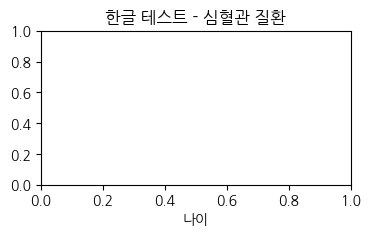

In [8]:
# 한글 폰트 설치
!apt-get install -y fonts-nanum
!fc-cache -fv

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 캐시 갱신
fm._load_fontmanager(try_read_cache=False)

# 나눔고딕 경로 찾기
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 테스트
plt.figure(figsize=(4,2))
plt.title('한글 테스트 - 심혈관 질환')
plt.xlabel('나이')
plt.show()

---
## 1단계. 환경 설정

In [1]:
!pip install -q gradio
!apt-get install -y fonts-nanum > /dev/null 2>&1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

fm._load_fontmanager(try_read_cache=False)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print('✅ 환경 설정 완료')

✅ 환경 설정 완료


---
## 2단계. 데이터 로딩 & 병합

In [3]:
# ── 파일 업로드 ───────────────────────────────────
from google.colab import files
print('cardio_train.csv 와 CVD_cleaned.csv 를 모두 선택하세요')
uploaded = files.upload()

cardio_train.csv 와 CVD_cleaned.csv 를 모두 선택하세요


Saving CVD_cleaned.csv to CVD_cleaned (1).csv
Saving cardio_train.csv to cardio_train.csv


In [4]:
# ── 데이터 로딩 ───────────────────────────────────
cardio = pd.read_csv('cardio_train.csv', sep=';')
cvd    = pd.read_csv('CVD_cleaned.csv')

print(f'cardio_train : {cardio.shape[0]:,}행 × {cardio.shape[1]}열')
print(f'CVD_cleaned  : {cvd.shape[0]:,}행 × {cvd.shape[1]}열')
print()
print('=== cardio_train 컬럼 ===')
print(list(cardio.columns))
print()
print('=== CVD_cleaned 컬럼 ===')
print(list(cvd.columns))

cardio_train : 70,000행 × 13열
CVD_cleaned  : 308,854행 × 19열

=== cardio_train 컬럼 ===
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

=== CVD_cleaned 컬럼 ===
['General_Health', 'Checkup', 'Exercise', 'Heart_Disease', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex', 'Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI', 'Smoking_History', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']


In [5]:
# ════════════════════════════════════════════════════════
#  두 데이터셋 병합 전략
#
#  cardio_train → 임상 수치 (혈압, 콜레스테롤 등) 보존
#  CVD_cleaned  → 식습관 컬럼만 추출해서 통계 기반으로 보강
#
#  직접 row-join 이 불가능하므로 (같은 환자가 아님)
#  아래 방법을 사용:
#  1) CVD에서 식습관 컬럼의 '심혈관 질환 여부별 평균' 계산
#  2) cardio_train 의 cardio(0/1) 기준으로 평균값 매핑
#  3) 개인 예측 시 식습관 직접 입력 → 피처로 활용
# ════════════════════════════════════════════════════════

# ── CVD 데이터 전처리 ─────────────────────────────
cvd_clean = cvd.copy()

# 타겟 변환 (Yes/No → 1/0)
cvd_clean['cardio'] = (cvd_clean['Heart_Disease'] == 'Yes').astype(int)

# 성별 변환
cvd_clean['gender'] = (cvd_clean['Sex'] == 'Male').astype(int) + 1  # 2=남성, 1=여성

# 나이 범주 → 중간값 변환
age_map = {
    '18-24':21, '25-29':27, '30-34':32, '35-39':37, '40-44':42,
    '45-49':47, '50-54':52, '55-59':57, '60-64':62, '65-69':67,
    '70-74':72, '75-79':77, '80+':82
}
cvd_clean['age_years'] = cvd_clean['Age_Category'].map(age_map)

# 운동/흡연/당뇨 변환
cvd_clean['active']    = (cvd_clean['Exercise']        == 'Yes').astype(int)
cvd_clean['smoke']     = (cvd_clean['Smoking_History'] == 'Yes').astype(int)
cvd_clean['diabetes']  = (cvd_clean['Diabetes']        == 'Yes').astype(int)

# 식습관 컬럼 정규화 (0~30 범위 → 0~1)
for col in ['Fruit_Consumption','Green_Vegetables_Consumption','FriedPotato_Consumption']:
    cvd_clean[col] = cvd_clean[col] / 30.0

# 음주량 정규화 (0~30)
cvd_clean['Alcohol_Consumption'] = cvd_clean['Alcohol_Consumption'] / 30.0

print('✅ CVD 데이터 전처리 완료')
print(f'   심혈관 질환 있음: {cvd_clean["cardio"].sum():,}명')
print(f'   심혈관 질환 없음: {(cvd_clean["cardio"]==0).sum():,}명')

✅ CVD 데이터 전처리 완료
   심혈관 질환 있음: 24,971명
   심혈관 질환 없음: 283,883명


In [9]:
# ── cardio_train 전처리 ───────────────────────────
df = cardio.copy()

# 이상치 제거
df = df[(df['ap_hi']>=60)   & (df['ap_hi']<=250)]
df = df[(df['ap_lo']>=40)   & (df['ap_lo']<=180)]
df = df[df['ap_hi'] > df['ap_lo']]
df = df[(df['height']>=140) & (df['height']<=210)]
df = df[(df['weight']>=30)  & (df['weight']<=200)]
df['bmi'] = df['weight'] / (df['height']/100)**2
df = df[(df['bmi']>=10)     & (df['bmi']<=60)]

# 파생 변수
df['age_years']      = (df['age']/365).astype(int)
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
df['hypertension']   = ((df['ap_hi']>=140)|(df['ap_lo']>=90)).astype(int)
df['bmi_category']   = pd.cut(df['bmi'], bins=[0,18.5,25,30,100],
                               labels=[0,1,2,3]).astype(int)

# ── CVD 식습관 통계를 cardio_train에 매핑 ──────────
# 심혈관 질환 여부별 식습관 평균 계산
diet_means = cvd_clean.groupby('cardio')[[
    'Fruit_Consumption','Green_Vegetables_Consumption',
    'FriedPotato_Consumption','Alcohol_Consumption'
]].mean()

# cardio_train 각 행에 해당 질환 여부의 평균 식습관 값 매핑
# (모델 학습용 - 실제 예측 시에는 사용자가 직접 입력)
for col in diet_means.columns:
    df[col] = df['cardio'].map(diet_means[col])
    # 약간의 노이즈 추가 (현실적인 분포 반영)
    std = cvd_clean[col].std()
    df[col] = df[col] + np.random.normal(0, std*0.3, len(df))
    df[col] = df[col].clip(0, 1)

# 당뇨: gluc >= 2 이면 당뇨 가능성 높음으로 매핑
df['diabetes'] = (df['gluc'] >= 2).astype(int)

print(f'✅ 데이터 병합 완료: {df.shape[0]:,}행 × {df.shape[1]}열')
print('추가된 식습관 컬럼:', ['Fruit_Consumption','Green_Vegetables_Consumption',
                           'FriedPotato_Consumption','Alcohol_Consumption','diabetes'])

✅ 데이터 병합 완료: 68,500행 × 23열
추가된 식습관 컬럼: ['Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption', 'Alcohol_Consumption', 'diabetes']


---
## 3단계. EDA (탐색적 데이터 분석)

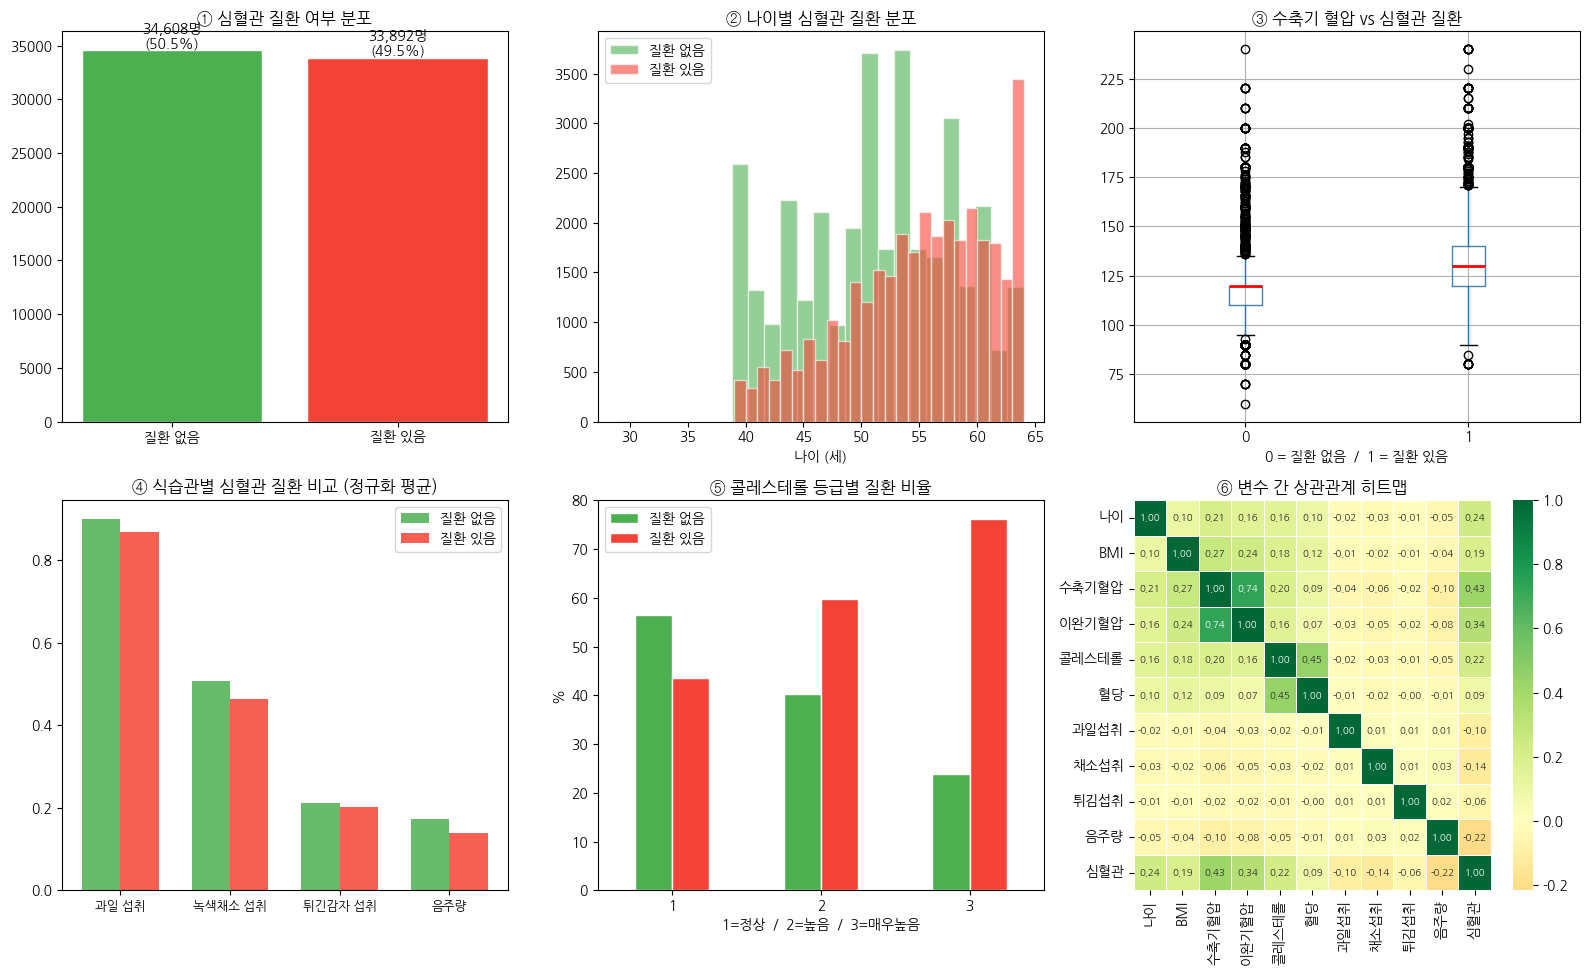

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('심혈관 질환 예측 - 탐색적 데이터 분석 (EDA)', fontsize=15, fontweight='bold', y=1.01)

# 1) 타겟 분포
counts = df['cardio'].value_counts()
axes[0,0].bar(['질환 없음','질환 있음'], counts.values, color=['#4CAF50','#F44336'], edgecolor='white')
axes[0,0].set_title('① 심혈관 질환 여부 분포')
for i,v in enumerate(counts.values):
    axes[0,0].text(i, v+200, f'{v:,}명\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

# 2) 나이 분포
for lbl, col in zip([0,1],['#4CAF50','#F44336']):
    axes[0,1].hist(df[df['cardio']==lbl]['age_years'], bins=25, alpha=0.6,
                   color=col, label='질환 없음' if lbl==0 else '질환 있음', edgecolor='white')
axes[0,1].set_title('② 나이별 심혈관 질환 분포')
axes[0,1].set_xlabel('나이 (세)')
axes[0,1].legend()

# 3) 혈압 박스플롯
df.boxplot(column='ap_hi', by='cardio', ax=axes[0,2],
           boxprops=dict(color='steelblue'), medianprops=dict(color='red', linewidth=2))
plt.sca(axes[0,2])
plt.title('③ 수축기 혈압 vs 심혈관 질환')
axes[0,2].set_xlabel('0 = 질환 없음  /  1 = 질환 있음')

# 4) 식습관 비교 (질환 여부별 평균)
diet_cols  = ['Fruit_Consumption','Green_Vegetables_Consumption','FriedPotato_Consumption','Alcohol_Consumption']
diet_names = ['과일 섭취','녹색채소 섭취','튀긴감자 섭취','음주량']
diet_avg   = df.groupby('cardio')[diet_cols].mean()
x = np.arange(len(diet_names))
w = 0.35
axes[1,0].bar(x-w/2, diet_avg.loc[0], w, label='질환 없음', color='#4CAF50', alpha=0.85)
axes[1,0].bar(x+w/2, diet_avg.loc[1], w, label='질환 있음', color='#F44336', alpha=0.85)
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(diet_names, fontsize=9)
axes[1,0].set_title('④ 식습관별 심혈관 질환 비교 (정규화 평균)')
axes[1,0].legend()

# 5) 콜레스테롤
ct = pd.crosstab(df['cholesterol'], df['cardio'], normalize='index')*100
ct.plot(kind='bar', ax=axes[1,1], color=['#4CAF50','#F44336'], edgecolor='white')
axes[1,1].set_title('⑤ 콜레스테롤 등급별 질환 비율')
axes[1,1].set_xlabel('1=정상  /  2=높음  /  3=매우높음')
axes[1,1].set_ylabel('%')
axes[1,1].legend(['질환 없음','질환 있음'])
axes[1,1].tick_params(axis='x', rotation=0)

# 6) 상관관계 히트맵
corr_cols   = ['age_years','bmi','ap_hi','ap_lo','cholesterol','gluc',
               'Fruit_Consumption','Green_Vegetables_Consumption',
               'FriedPotato_Consumption','Alcohol_Consumption','cardio']
corr_labels = ['나이','BMI','수축기혈압','이완기혈압','콜레스테롤','혈당',
               '과일섭취','채소섭취','튀김섭취','음주량','심혈관']
corr_df = df[corr_cols].copy()
corr_df.columns = corr_labels
sns.heatmap(corr_df.corr(), ax=axes[1,2], annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5, annot_kws={'size':7})
axes[1,2].set_title('⑥ 변수 간 상관관계 히트맵')

plt.suptitle('')
plt.tight_layout()
plt.show()

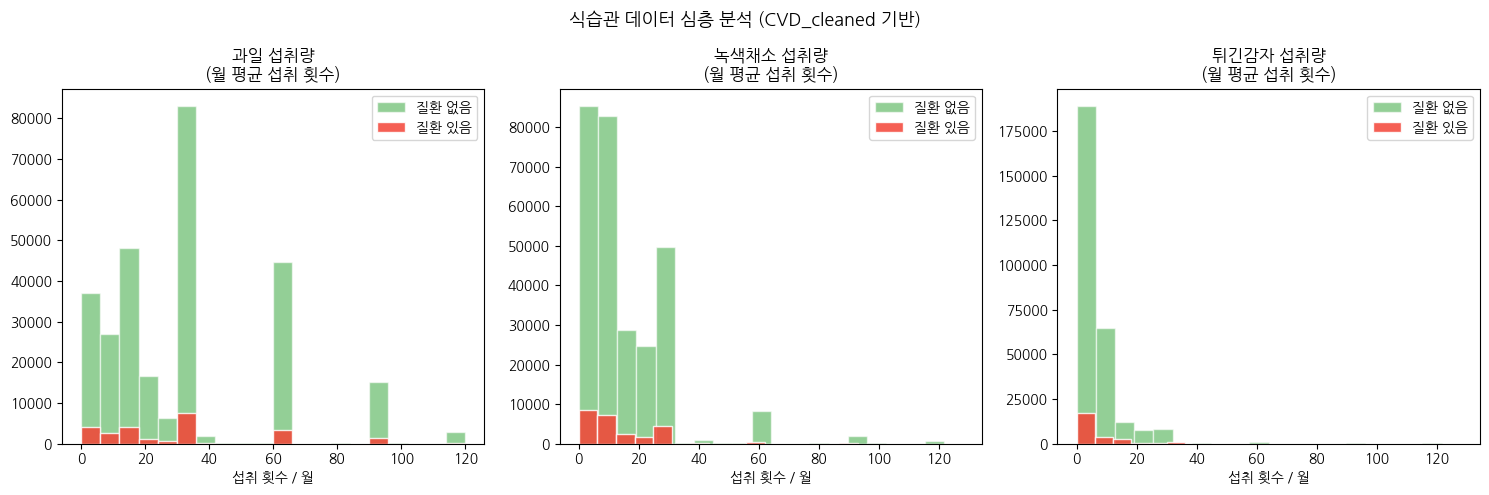

※ 과일·채소 섭취가 많을수록 질환 비율 감소, 튀긴음식은 반대 경향


In [11]:
# ── CVD 데이터셋 식습관 심층 분석 ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('식습관 데이터 심층 분석 (CVD_cleaned 기반)', fontsize=13, fontweight='bold')

diet_plot = [
    ('Fruit_Consumption',             '과일 섭취량',     '#FF9800'),
    ('Green_Vegetables_Consumption',  '녹색채소 섭취량', '#4CAF50'),
    ('FriedPotato_Consumption',       '튀긴감자 섭취량', '#F44336'),
]

for ax, (col, label, color) in zip(axes, diet_plot):
    for lbl, alpha in zip([0,1],[0.6, 0.85]):
        subset = cvd_clean[cvd_clean['cardio']==lbl][col] * 30
        ax.hist(subset, bins=20, alpha=alpha, color='#4CAF50' if lbl==0 else '#F44336',
                label='질환 없음' if lbl==0 else '질환 있음', edgecolor='white')
    ax.set_title(f'{label}\n(월 평균 섭취 횟수)')
    ax.set_xlabel('섭취 횟수 / 월')
    ax.legend()

plt.tight_layout()
plt.show()
print('※ 과일·채소 섭취가 많을수록 질환 비율 감소, 튀긴음식은 반대 경향')

---
## 4단계. 전처리 & 모델 학습

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              classification_report, confusion_matrix)
from xgboost import XGBClassifier

# ── 최종 피처 목록 (식습관 포함) ──────────────────
FEATURES = [
    # 임상 수치
    'age_years', 'gender', 'height', 'weight', 'bmi',
    'ap_hi', 'ap_lo', 'pulse_pressure', 'hypertension',
    'cholesterol', 'gluc', 'smoke', 'alco', 'active',
    'bmi_category', 'diabetes',
    # 식습관 (CVD 데이터셋에서 추가)
    'Fruit_Consumption', 'Green_Vegetables_Consumption',
    'FriedPotato_Consumption', 'Alcohol_Consumption'
]

X = df[FEATURES]
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── XGBoost 학습 ──────────────────────────────────
model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=42, eval_metric='logloss',
    use_label_encoder=False, n_jobs=-1
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print('✅ 모델 학습 완료')
print(f'   정확도  : {accuracy_score(y_test, y_pred):.4f}')
print(f'   AUC-ROC : {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['질환 없음','질환 있음']))

✅ 모델 학습 완료
   정확도  : 0.7464
   AUC-ROC : 0.8185

              precision    recall  f1-score   support

       질환 없음       0.74      0.77      0.75      6922
       질환 있음       0.75      0.72      0.74      6778

    accuracy                           0.75     13700
   macro avg       0.75      0.75      0.75     13700
weighted avg       0.75      0.75      0.75     13700



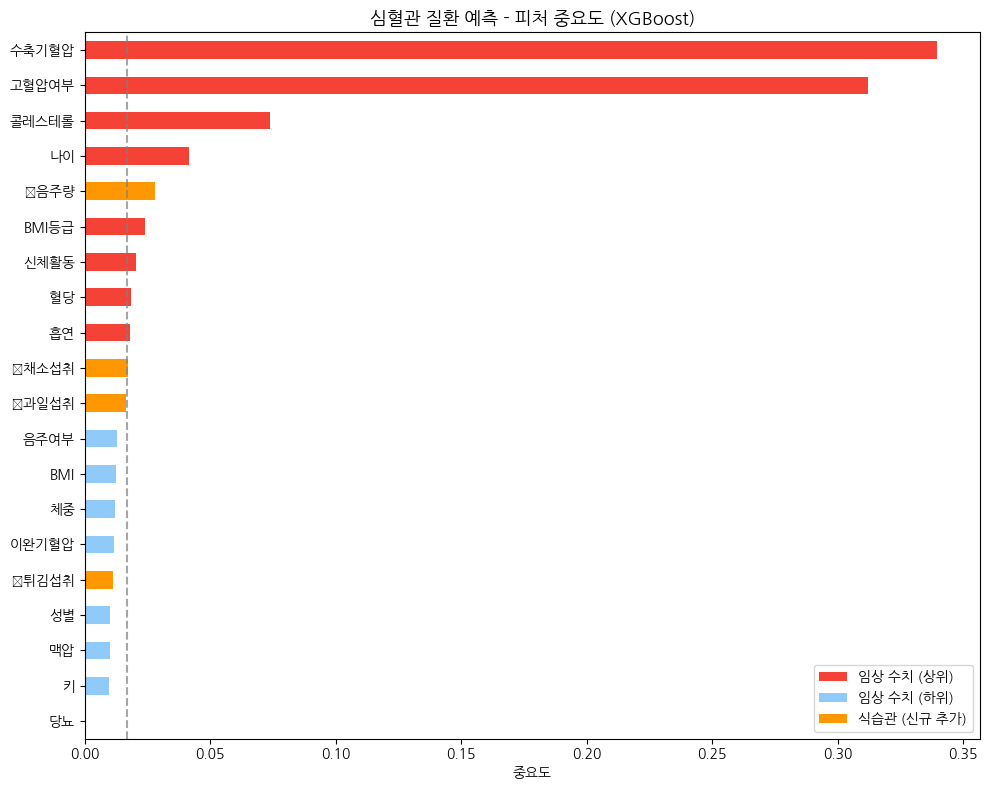

In [13]:
# ── 피처 중요도 시각화 ────────────────────────────
feat_labels = {
    'age_years':'나이', 'gender':'성별', 'height':'키', 'weight':'체중',
    'bmi':'BMI', 'ap_hi':'수축기혈압', 'ap_lo':'이완기혈압',
    'pulse_pressure':'맥압', 'hypertension':'고혈압여부',
    'cholesterol':'콜레스테롤', 'gluc':'혈당', 'smoke':'흡연',
    'alco':'음주여부', 'active':'신체활동', 'bmi_category':'BMI등급',
    'diabetes':'당뇨',
    'Fruit_Consumption':'🍎과일섭취',
    'Green_Vegetables_Consumption':'🥦채소섭취',
    'FriedPotato_Consumption':'🍟튀김섭취',
    'Alcohol_Consumption':'🍺음주량'
}

feat_imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
feat_imp.index = [feat_labels.get(f,f) for f in feat_imp.index]

diet_feats = ['🍎과일섭취','🥦채소섭취','🍟튀김섭취','🍺음주량']
colors_bar = []
for name in feat_imp.index:
    if name in diet_feats:
        colors_bar.append('#FF9800')   # 식습관 = 주황
    elif feat_imp[name] > feat_imp.median():
        colors_bar.append('#F44336')   # 상위 중요도 = 빨강
    else:
        colors_bar.append('#90CAF9')   # 하위 = 파랑

plt.figure(figsize=(10, 8))
feat_imp.plot(kind='barh', color=colors_bar)
plt.axvline(feat_imp.median(), color='gray', linestyle='--', alpha=0.7, label='중간값')
plt.title('심혈관 질환 예측 - 피처 중요도 (XGBoost)', fontsize=13, fontweight='bold')
plt.xlabel('중요도')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#F44336', label='임상 수치 (상위)'),
    Patch(facecolor='#90CAF9', label='임상 수치 (하위)'),
    Patch(facecolor='#FF9800', label='식습관 (신규 추가)'),
]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

---
## 5단계. 개인 정보 입력 → 예측 + 음식 추천
> 아래 `MY_INFO` 에 본인 정보를 입력하세요.

In [14]:
# ── 규칙 기반 음식 추천 데이터 ────────────────────
FOOD_RULES = {
    'high_bp': {
        'icon': '🩺', 'reason': '고혈압 (수축기 ≥ 140 또는 이완기 ≥ 90)',
        'avoid': ['라면·짜개·젓갈 등 고나트륨 음식', '소시지·햄·베이컨 등 가공육',
                  '치즈·버터 등 고지방 유제품', '커피 3잔 이상/일 (카페인 과다)',
                  '인스턴트·냉동식품']
    },
    'high_chol': {
        'icon': '🧪', 'reason': '콜레스테롤 높음',
        'avoid': ['치킨·감자튀김 등 튀긴 음식', '삼겹살·갈비 등 붉은 육류 과다',
                  '버터·마가린·쇼트닝', '크림소스·마요네즈',
                  '달걀 노른자 과다 섭취']
    },
    'high_gluc': {
        'icon': '🍬', 'reason': '혈당 높음 / 당뇨',
        'avoid': ['흰쌀밥·흰빵·떡 등 정제 탄수화물', '콜라·주스·에너지드링크 등 당음료',
                  '과자·케이크·도넛', '아이스크림·빙수·시럽',
                  '과일주스 (과당 과다)']
    },
    'obese': {
        'icon': '⚖️', 'reason': 'BMI 25 이상 (과체중/비만)',
        'avoid': ['햄버거·피자 등 고열량 패스트푸드', '야식', '술안주류',
                  '크림·버터 베이스 음식', '단 음료 및 디저트류']
    },
    'high_fried': {
        'icon': '🍟', 'reason': '튀긴 음식 과다 섭취',
        'avoid': ['감자튀김·치킨·돈가스 등 튀김류', '도넛·크루아상 등 기름진 빵',
                  '팝콘 (버터/오일 다량)', '중국요리 (기름 과다)',
                  '인스턴트 라면 (유탕면)']
    },
    'low_veg': {
        'icon': '🥦', 'reason': '채소·과일 섭취 부족',
        'avoid': ['채소 없는 식단 (고기+탄수화물만)', '가공 주스 (생과일 대체 불가)',
                  '통조림 채소 (나트륨 과다)', '과도한 육류 위주 식사']
    },
    'smoker': {
        'icon': '🚬', 'reason': '흡연자',
        'avoid': ['알코올 (흡연+음주 시 심혈관 위험 급증)', '카페인 고용량',
                  '포화지방 많은 음식']
    },
    'heavy_drinker': {
        'icon': '🍺', 'reason': '음주량 많음',
        'avoid': ['고염분 안주 (오징어채·땅콩)', '튀김 안주',
                  '야식 배달음식', '탄산음료 + 주류 혼합']
    }
}

def rule_based_foods(ap_hi, ap_lo, cholesterol, gluc, bmi,
                     smoke, diabetes, fruit, vegetable, fried, alcohol):
    recs = []
    if ap_hi >= 140 or ap_lo >= 90:  recs.append(FOOD_RULES['high_bp'])
    if cholesterol >= 2:              recs.append(FOOD_RULES['high_chol'])
    if gluc >= 2 or diabetes == 1:   recs.append(FOOD_RULES['high_gluc'])
    if bmi >= 25:                     recs.append(FOOD_RULES['obese'])
    if fried > 0.5:                   recs.append(FOOD_RULES['high_fried'])   # 월 15회 이상
    if fruit < 0.3 or vegetable < 0.3: recs.append(FOOD_RULES['low_veg'])    # 월 9회 미만
    if smoke == 1:                    recs.append(FOOD_RULES['smoker'])
    if alcohol > 0.3:                 recs.append(FOOD_RULES['heavy_drinker']) # 월 9회 이상
    return recs

print('✅ 음식 추천 규칙 로딩 완료')

✅ 음식 추천 규칙 로딩 완료


            🫀 심혈관 질환 예측 결과
  예측 확률  : 9.2%
  위험 등급  : 🟢 저위험
  BMI        : 22.9  (정상)
  고혈압 여부: 해당 없음


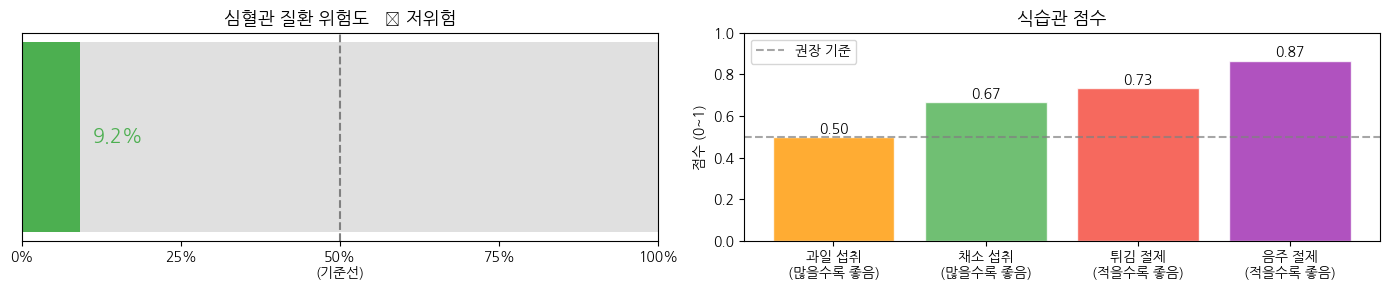


📋 위험 요인별 피해야 할 음식
----------------------------------------------------------
  ✅ 현재 주요 위험 요인이 없습니다. 균형 잡힌 식단을 유지하세요!


In [15]:
# ════════════════════════════════════════════════
#  ✏️  여기에 본인 정보를 입력하세요
# ════════════════════════════════════════════════
MY_INFO = {
    # 기본 정보
    'age'        : 25,    # 나이 (세)
    'gender'     : 2,     # 성별: 1=여성, 2=남성
    'height'     : 175,   # 키 (cm)
    'weight'     : 70,    # 체중 (kg)
    # 임상 수치
    'ap_hi'      : 120,   # 수축기 혈압 (mmHg)
    'ap_lo'      : 80,    # 이완기 혈압 (mmHg)
    'cholesterol': 1,     # 1=정상 / 2=높음 / 3=매우높음
    'gluc'       : 1,     # 1=정상 / 2=높음 / 3=매우높음
    'smoke'      : 0,     # 0=비흡연 / 1=흡연
    'alco'       : 0,     # 0=비음주 / 1=음주
    'active'     : 1,     # 0=비활동 / 1=활동
    'diabetes'   : 0,     # 0=없음 / 1=있음
    # 식습관 (월 평균 섭취 횟수, 0~30)
    'fruit_monthly'     : 15,  # 과일 섭취 횟수/월
    'vegetable_monthly' : 20,  # 녹색채소 섭취 횟수/월
    'fried_monthly'     : 8,   # 튀긴음식 섭취 횟수/월
    'alcohol_monthly'   : 4,   # 음주 횟수/월
}
# ════════════════════════════════════════════════

# 파생 변수 계산
bmi            = MY_INFO['weight'] / (MY_INFO['height']/100)**2
pulse_pressure = MY_INFO['ap_hi'] - MY_INFO['ap_lo']
hypertension   = int(MY_INFO['ap_hi']>=140 or MY_INFO['ap_lo']>=90)
bmi_category   = 0 if bmi<18.5 else (1 if bmi<25 else (2 if bmi<30 else 3))
# 식습관 정규화
fruit_norm = MY_INFO['fruit_monthly'] / 30
veg_norm   = MY_INFO['vegetable_monthly'] / 30
fried_norm = MY_INFO['fried_monthly'] / 30
alco_norm  = MY_INFO['alcohol_monthly'] / 30

input_data = pd.DataFrame([{
    'age_years': MY_INFO['age'], 'gender': MY_INFO['gender'],
    'height': MY_INFO['height'], 'weight': MY_INFO['weight'], 'bmi': bmi,
    'ap_hi': MY_INFO['ap_hi'], 'ap_lo': MY_INFO['ap_lo'],
    'pulse_pressure': pulse_pressure, 'hypertension': hypertension,
    'cholesterol': MY_INFO['cholesterol'], 'gluc': MY_INFO['gluc'],
    'smoke': MY_INFO['smoke'], 'alco': MY_INFO['alco'],
    'active': MY_INFO['active'], 'bmi_category': bmi_category,
    'diabetes': MY_INFO['diabetes'],
    'Fruit_Consumption': fruit_norm,
    'Green_Vegetables_Consumption': veg_norm,
    'FriedPotato_Consumption': fried_norm,
    'Alcohol_Consumption': alco_norm,
}])

prob    = model.predict_proba(input_data)[0][1]
risk_lv = '🔴 고위험' if prob>=0.6 else ('🟡 중간위험' if prob>=0.4 else '🟢 저위험')
bmi_str = ['저체중','정상','과체중','비만'][bmi_category]

# ── 결과 출력 ─────────────────────────────────────
print('=' * 58)
print('            🫀 심혈관 질환 예측 결과')
print('=' * 58)
print(f'  예측 확률  : {prob*100:.1f}%')
print(f'  위험 등급  : {risk_lv}')
print(f'  BMI        : {bmi:.1f}  ({bmi_str})')
print(f'  고혈압 여부: {"해당" if hypertension else "해당 없음"}')
print('=' * 58)

# ── 위험도 게이지 ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

bar_color = '#F44336' if prob>=0.6 else ('#FF9800' if prob>=0.4 else '#4CAF50')
axes[0].barh(0, 1, color='#E0E0E0', height=0.4)
axes[0].barh(0, prob, color=bar_color, height=0.4)
axes[0].axvline(0.5, color='gray', linestyle='--', linewidth=1.5)
axes[0].text(min(prob+0.02, 0.95), 0, f'{prob*100:.1f}%',
             va='center', fontsize=14, fontweight='bold', color=bar_color)
axes[0].set_xlim(0,1); axes[0].set_yticks([])
axes[0].set_xticks([0,0.25,0.5,0.75,1.0])
axes[0].set_xticklabels(['0%','25%','50%\n(기준선)','75%','100%'])
axes[0].set_title(f'심혈관 질환 위험도   {risk_lv}', fontsize=13, fontweight='bold')

# 식습관 레이더 대신 바 차트
diet_vals  = [fruit_norm, veg_norm, 1-fried_norm, 1-alco_norm]
diet_names = ['과일 섭취\n(많을수록 좋음)', '채소 섭취\n(많을수록 좋음)',
              '튀김 절제\n(적을수록 좋음)', '음주 절제\n(적을수록 좋음)']
diet_colors = ['#FF9800','#4CAF50','#F44336','#9C27B0']
bars = axes[1].bar(diet_names, diet_vals, color=diet_colors, alpha=0.8, edgecolor='white')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='권장 기준')
axes[1].set_ylim(0,1); axes[1].set_ylabel('점수 (0~1)')
axes[1].set_title('식습관 점수', fontsize=13, fontweight='bold')
axes[1].legend()
for bar, val in zip(bars, diet_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{val:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# ── 규칙 기반 음식 추천 ───────────────────────────
print('\n📋 위험 요인별 피해야 할 음식')
print('-' * 58)
food_recs = rule_based_foods(
    MY_INFO['ap_hi'], MY_INFO['ap_lo'], MY_INFO['cholesterol'],
    MY_INFO['gluc'], bmi, MY_INFO['smoke'], MY_INFO['diabetes'],
    fruit_norm, veg_norm, fried_norm, alco_norm
)

if not food_recs:
    print('  ✅ 현재 주요 위험 요인이 없습니다. 균형 잡힌 식단을 유지하세요!')
else:
    for rec in food_recs:
        print(f'\n  {rec["icon"]} {rec["reason"]}')
        for food in rec['avoid']:
            print(f'      • {food}')

---
## 6단계. Gradio 웹 UI

In [16]:
import gradio as gr
import matplotlib
matplotlib.use('Agg')

def predict_and_recommend(age, gender, height, weight,
                           ap_hi, ap_lo, cholesterol, gluc,
                           smoke, alco, active, diabetes,
                           fruit_m, veg_m, fried_m, alcohol_m):

    gender_code = 2 if gender=='남성' else 1
    smoke_code  = 1 if smoke=='흡연' else 0
    alco_code   = 1 if alco=='음주' else 0
    active_code = 1 if active=='활동' else 0
    diab_code   = 1 if diabetes=='있음' else 0
    chol_code   = {'정상':1,'높음':2,'매우높음':3}[cholesterol]
    gluc_code   = {'정상':1,'높음':2,'매우높음':3}[gluc]

    bmi_v   = weight / (height/100)**2
    pulse_v = ap_hi - ap_lo
    hyp_v   = int(ap_hi>=140 or ap_lo>=90)
    bmi_cat = 0 if bmi_v<18.5 else (1 if bmi_v<25 else (2 if bmi_v<30 else 3))
    bmi_str = ['저체중','정상','과체중','비만'][bmi_cat]

    fruit_n  = fruit_m  / 30
    veg_n    = veg_m    / 30
    fried_n  = fried_m  / 30
    alco_n   = alcohol_m / 30

    inp = pd.DataFrame([{
        'age_years':age, 'gender':gender_code, 'height':height, 'weight':weight,
        'bmi':bmi_v, 'ap_hi':ap_hi, 'ap_lo':ap_lo,
        'pulse_pressure':pulse_v, 'hypertension':hyp_v,
        'cholesterol':chol_code, 'gluc':gluc_code,
        'smoke':smoke_code, 'alco':alco_code, 'active':active_code,
        'bmi_category':bmi_cat, 'diabetes':diab_code,
        'Fruit_Consumption':fruit_n, 'Green_Vegetables_Consumption':veg_n,
        'FriedPotato_Consumption':fried_n, 'Alcohol_Consumption':alco_n,
    }])

    prob   = model.predict_proba(inp)[0][1]
    risk   = '🔴 고위험' if prob>=0.6 else ('🟡 중간위험' if prob>=0.4 else '🟢 저위험')
    summary = (
        f'예측 확률: {prob*100:.1f}%   위험 등급: {risk}\n'
        f'BMI: {bmi_v:.1f} ({bmi_str})   고혈압: {"해당" if hyp_v else "해당 없음"}'
    )

    # 게이지 + 식습관 점수
    fig, axes = plt.subplots(1, 2, figsize=(13, 3))
    bar_color = '#F44336' if prob>=0.6 else ('#FF9800' if prob>=0.4 else '#4CAF50')
    axes[0].barh(0, 1, color='#E0E0E0', height=0.4)
    axes[0].barh(0, prob, color=bar_color, height=0.4)
    axes[0].axvline(0.5, color='gray', linestyle='--')
    axes[0].text(min(prob+0.02,0.95), 0, f'{prob*100:.1f}%',
                 va='center', fontsize=13, fontweight='bold', color=bar_color)
    axes[0].set_xlim(0,1); axes[0].set_yticks([])
    axes[0].set_xticks([0,0.25,0.5,0.75,1.0])
    axes[0].set_xticklabels(['0%','25%','50%','75%','100%'])
    axes[0].set_title(f'위험도   {risk}', fontsize=12, fontweight='bold')

    diet_vals  = [fruit_n, veg_n, 1-fried_n, 1-alco_n]
    diet_names = ['과일섭취','채소섭취','튀김절제','음주절제']
    diet_colors = ['#FF9800','#4CAF50','#F44336','#9C27B0']
    bars = axes[1].bar(diet_names, diet_vals, color=diet_colors, alpha=0.8)
    axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.7)
    axes[1].set_ylim(0,1); axes[1].set_title('식습관 점수', fontsize=12, fontweight='bold')
    for bar, val in zip(bars, diet_vals):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                     f'{val:.2f}', ha='center', fontsize=10)
    plt.tight_layout()

    # 규칙 기반 음식 추천
    food_recs = rule_based_foods(
        ap_hi, ap_lo, chol_code, gluc_code, bmi_v,
        smoke_code, diab_code, fruit_n, veg_n, fried_n, alco_n
    )
    if not food_recs:
        rule_text = '✅ 현재 주요 위험 요인이 없습니다!\n균형 잡힌 식단을 유지하세요.'
    else:
        lines = []
        for rec in food_recs:
            lines.append(f'{rec["icon"]} {rec["reason"]}')
            for food in rec['avoid']:
                lines.append(f'  • {food}')
            lines.append('')
        rule_text = '\n'.join(lines)

    return summary, fig, rule_text


# ── Gradio UI ─────────────────────────────────────
with gr.Blocks(title='🫀 심혈관 질환 예측', theme=gr.themes.Soft()) as demo:
    gr.Markdown('# 🫀 심혈관 질환 위험도 예측 & 맞춤 음식 추천')
    gr.Markdown('개인 건강 정보와 식습관을 입력하면 심혈관 질환 위험도와 피해야 할 음식을 알려드립니다.')

    with gr.Row():
        with gr.Column():
            gr.Markdown('### 📝 기본 정보')
            age    = gr.Slider(20, 80, value=30, step=1,   label='나이 (세)')
            gender = gr.Radio(['남성','여성'], value='남성', label='성별')
            height = gr.Slider(140, 210, value=170, step=1, label='키 (cm)')
            weight = gr.Slider(30, 150, value=70, step=0.5, label='체중 (kg)')

        with gr.Column():
            gr.Markdown('### 🩺 검진 수치')
            ap_hi       = gr.Slider(60, 250, value=120, step=1, label='수축기 혈압 (mmHg)')
            ap_lo       = gr.Slider(40, 180, value=80,  step=1, label='이완기 혈압 (mmHg)')
            cholesterol = gr.Radio(['정상','높음','매우높음'], value='정상', label='콜레스테롤')
            gluc        = gr.Radio(['정상','높음','매우높음'], value='정상', label='혈당')
            diabetes    = gr.Radio(['없음','있음'], value='없음', label='당뇨')

        with gr.Column():
            gr.Markdown('### 🚬 생활 습관')
            smoke  = gr.Radio(['비흡연','흡연'], value='비흡연', label='흡연')
            alco   = gr.Radio(['비음주','음주'], value='비음주', label='음주')
            active = gr.Radio(['비활동','활동'], value='활동',   label='신체활동')

    gr.Markdown('### 🍽️ 식습관 (월 평균 섭취 횟수)')
    with gr.Row():
        fruit_m   = gr.Slider(0, 30, value=15, step=1, label='🍎 과일 섭취 횟수/월')
        veg_m     = gr.Slider(0, 30, value=15, step=1, label='🥦 녹색채소 섭취 횟수/월')
        fried_m   = gr.Slider(0, 30, value=8,  step=1, label='🍟 튀긴음식 섭취 횟수/월')
        alcohol_m = gr.Slider(0, 30, value=4,  step=1, label='🍺 음주 횟수/월')

    btn = gr.Button('🔍 예측 & 추천 받기', variant='primary', size='lg')

    gr.Markdown('---')
    gr.Markdown('## 📊 결과')
    summary_box = gr.Textbox(label='예측 요약', lines=2)
    gauge_plot  = gr.Plot(label='위험도 & 식습관 점수')
    rule_box    = gr.Textbox(label='📋 피해야 할 음식 추천', lines=15, max_lines=25)

    btn.click(
        fn=predict_and_recommend,
        inputs=[age, gender, height, weight,
                ap_hi, ap_lo, cholesterol, gluc,
                smoke, alco, active, diabetes,
                fruit_m, veg_m, fried_m, alcohol_m],
        outputs=[summary_box, gauge_plot, rule_box]
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://244bb64f8ada754675.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
